# The Ocean's Longest Diving Animals

How long can air-breathing animals hold their breath while diving? Which animals can stay submerged for the longest time?

The file `longest-diving-animals.csv` contains the recorded durations, in minutes, of the longest dives ever recorded in the scientific literature for different species of marine mammals. 

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'longest-diving-animals.csv'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('longest-diving-animals.csv')
df.head()

,animal,category,duration
0,Emperor Penguin,penguins,32.2
1,King Penguin,penguins,9.2
2,Rockhopper Penguin,penguins,3.2
3,Macaroni Penguin,penguins,6.3
4,Royal Penguin,penguins,7.5


### Project Ideas

- Create horizontal bar plots to show the longest diving animals, either for each category or within a category.

- Follow the Pro Tips.

- Convert dive durations from minutes to hours for easier understanding - 2.5 hours is clearer than 150 minutes.

- Add a reference bar to help readers build intuition about the durations. 

Side Note: The longest time a person has held their breath underwater is 24 minutes 37 seconds. This was done at the surface of a pool, not while freediving, so it might not directly comparable.


In [3]:
# YOUR CODE HERE (add additional cells as needed)

In [4]:
# ── Convert duration from minutes to hours ────────────────────────────────────
df['duration_hrs'] = df['duration'] / 60
df

,animal,category,duration,duration_hrs
0,Emperor Penguin,penguins,32.2,0.536667
1,King Penguin,penguins,9.2,0.153333
2,Rockhopper Penguin,penguins,3.2,0.053333
3,Macaroni Penguin,penguins,6.3,0.105000
4,Royal Penguin,penguins,7.5,0.125000
...,...,...,...,...
103,North Atlantic Right Whale,baleen whales,16.3,0.271667
104,Humpback Whale,baleen whales,24.0,0.400000
105,Atlantic Walrus,walruses,49.0,0.816667
106,Dungong,other marine mammals,10.0,0.166667


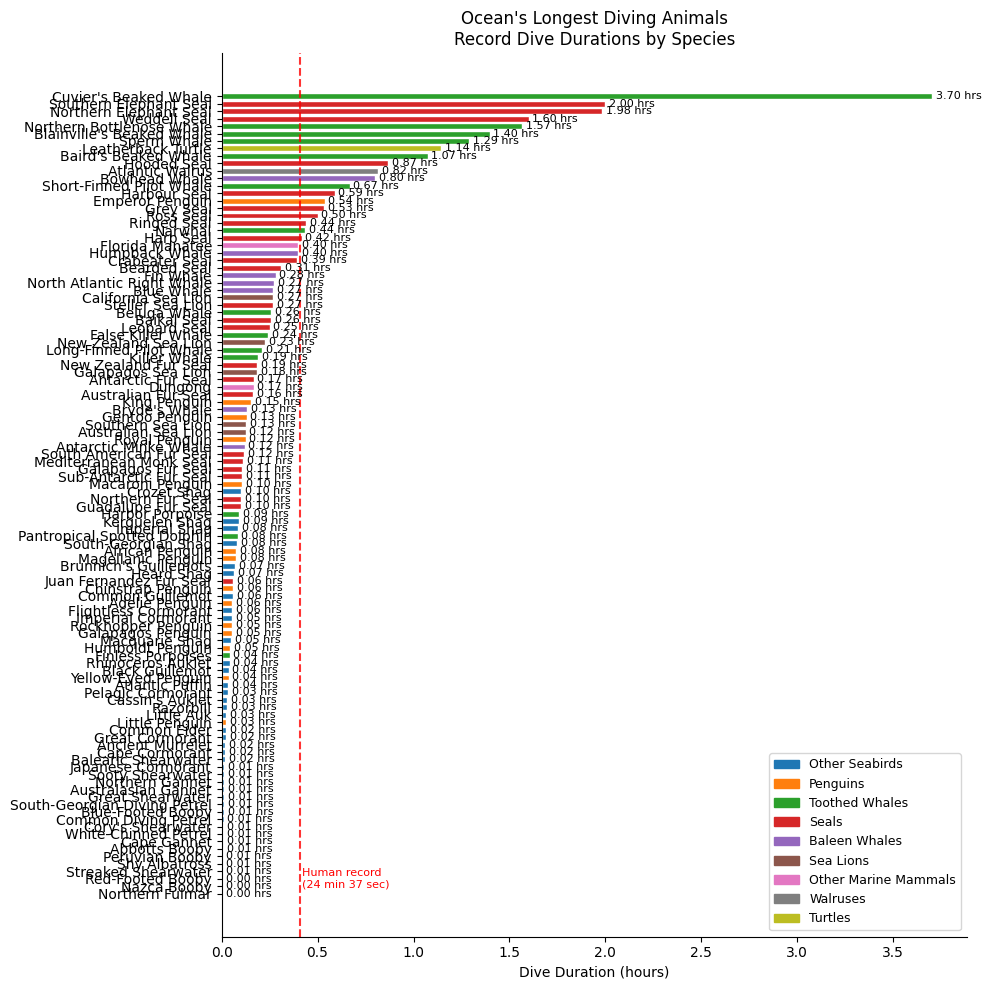

In [5]:
# ── 1. Overall chart: ALL animals sorted by dive duration ─────────────────────
HUMAN_RECORD_HRS = 24.617 / 60  # 24 min 37 sec

df_sorted = df.sort_values('duration_hrs', ascending=True)

plt.figure(figsize=(10, 10))

# Color bars by category
categories = df_sorted['category'].unique()
color_map = {cat: plt.cm.tab10(i) for i, cat in enumerate(categories)}
colors = df_sorted['category'].map(color_map)

bars = plt.barh(df_sorted['animal'], df_sorted['duration_hrs'],
                color=colors, edgecolor='white')

# Human breath-hold reference line
plt.axvline(x=HUMAN_RECORD_HRS, color='red', linestyle='--',
            linewidth=1.5, alpha=0.8, label=f'Human record ({24/60:.2f} hrs)')
plt.text(HUMAN_RECORD_HRS + 0.01, 0.5, 'Human record\n(24 min 37 sec)',
         color='red', fontsize=8, va='bottom')

# Add duration labels on bars
for bar, val in zip(bars, df_sorted['duration_hrs']):
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f} hrs', va='center', fontsize=8)

# Legend for categories
from matplotlib.patches import Patch
legend_handles = [Patch(color=color_map[cat], label=cat.title()) for cat in categories]
plt.legend(handles=legend_handles, loc='lower right', fontsize=9)

plt.xlabel('Dive Duration (hours)')
plt.title("Ocean's Longest Diving Animals\nRecord Dive Durations by Species")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

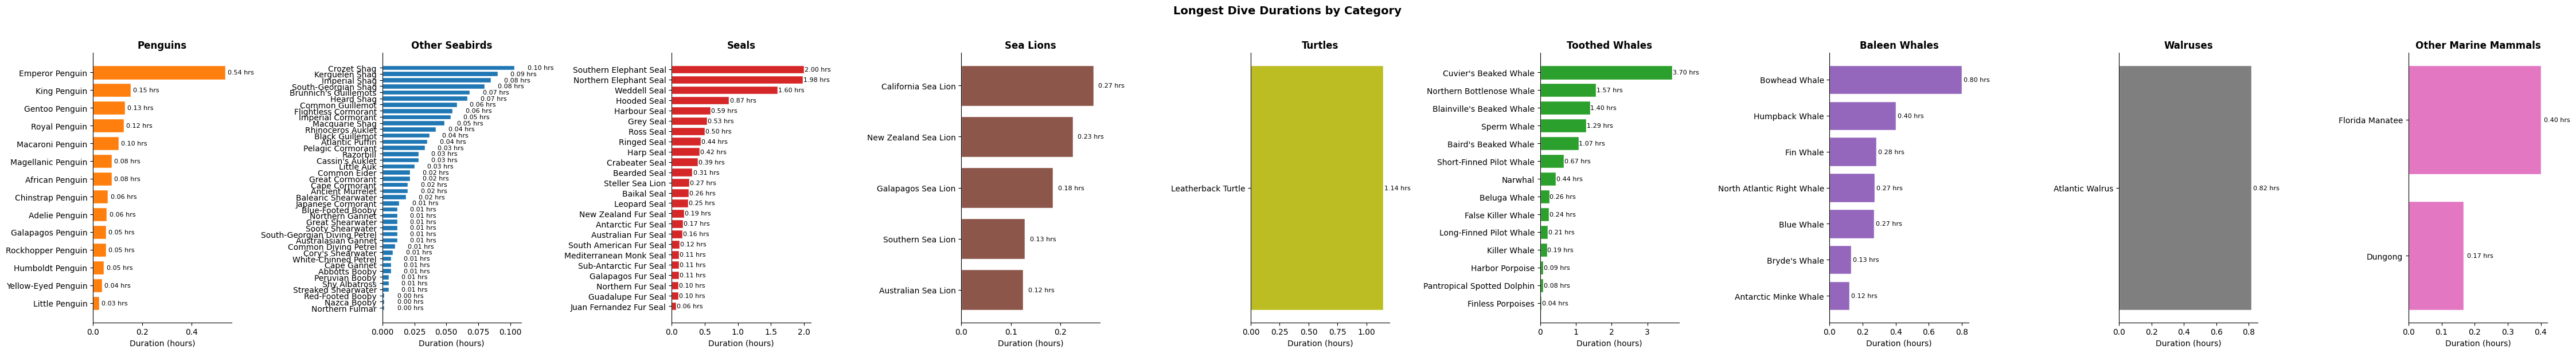

In [6]:
# ── 2. One chart per category ─────────────────────────────────────────────────
categories = df['category'].unique()
n_cats = len(categories)

fig, axes = plt.subplots(1, n_cats, figsize=(5 * n_cats, 6))
if n_cats == 1:
    axes = [axes]

for ax, cat in zip(axes, categories):
    subset = df[df['category'] == cat].sort_values('duration_hrs', ascending=True)
    color = color_map[cat]

    bars = ax.barh(subset['animal'], subset['duration_hrs'],
                   color=color, edgecolor='white')

    # Bar labels
    for bar, val in zip(bars, subset['duration_hrs']):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f} hrs', va='center', fontsize=8)

    ax.set_title(cat.title(), fontweight='bold')
    ax.set_xlabel('Duration (hours)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle("Longest Dive Durations by Category", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# ── 3. Summary: Top 5 longest divers overall ─────────────────────────────────
print("Top 5 Longest Diving Animals")
print("=" * 40)
top5 = df.sort_values('duration_hrs', ascending=False).head(5)
for _, row in top5.iterrows():
    print(f"{row['animal']:25s}  {row['duration_hrs']:.2f} hrs  ({row['duration']} min)  [{row['category']}]")

Top 5 Longest Diving Animals
Cuvier's Beaked Whale      3.70 hrs  (222.0 min)  [toothed whales]
Southern Elephant Seal     2.00 hrs  (120.0 min)  [seals]
Northern Elephant Seal     1.98 hrs  (119.0 min)  [seals]
Weddell Seal               1.60 hrs  (96.0 min)  [seals]
Northern Bottlenose Whale  1.57 hrs  (94.0 min)  [toothed whales]


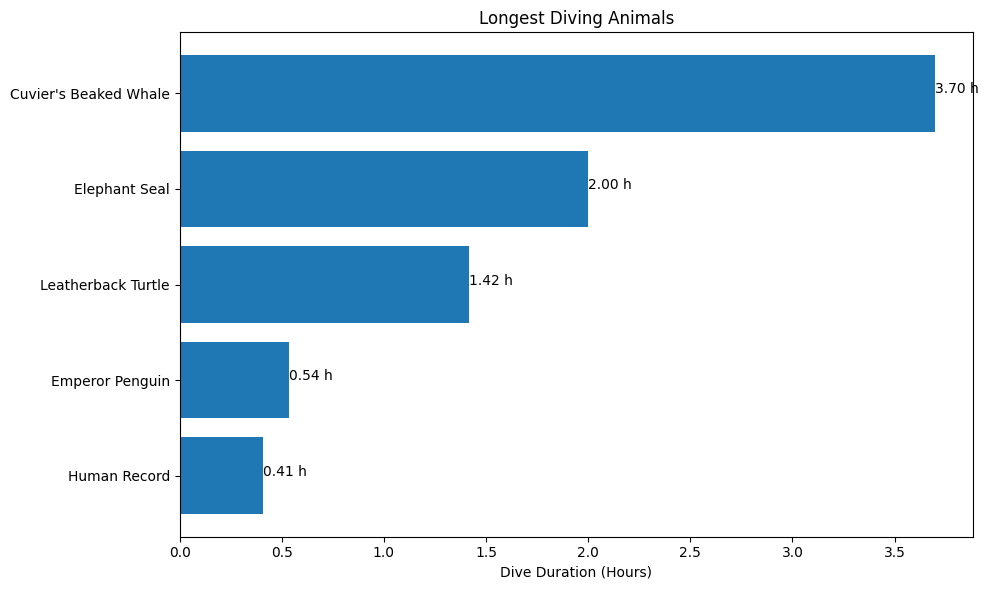

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample dataset
data = {
    "animal": [
        "Emperor Penguin",
        "Cuvier's Beaked Whale",
        "Elephant Seal",
        "Leatherback Turtle",
        "Human Record"
    ],
    
    "category": [
        "penguins",
        "whales",
        "seals",
        "turtles",
        "human"
    ],
    
    "duration_minutes": [
        32.2,
        222,
        120,
        85,
        24.62
    ]
}

df = pd.DataFrame(data)

# Convert to hours
df["duration_hours"] = df["duration_minutes"] / 60

# Sort values
df = df.sort_values("duration_hours")

# Create plot
plt.figure(figsize=(10,6))

plt.barh(
    df["animal"],
    df["duration_hours"]
)

plt.xlabel("Dive Duration (Hours)")
plt.title("Longest Diving Animals")

# Add labels
for index, value in enumerate(df["duration_hours"]):
    plt.text(value, index, f"{value:.2f} h")

plt.tight_layout()
plt.show()